# Question 1 -- Implementation checks (1.(e))

Only code lives here: an environment check, then one check per step of `FlexibleConsumerModel.build()` in `src/model.py`. Edit the `.py` file, save it, and re-run from the "build" cell downwards (`autoreload` picks up the changes). Figures, tables and commentary for 1.(f) are added once the model works.

In [13]:
import sys
from pathlib import Path

%load_ext autoreload
%autoreload 2

ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import gurobipy as gp
import numpy as np
import pandas as pd
from gurobipy import GRB

from src.data_loader import load_question
from src.model import FlexibleConsumerModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. Environment check

In [14]:
print(f"Python {sys.version.split()[0]} | gurobipy {gp.gurobi.version()} | numpy {np.__version__} | pandas {pd.__version__}")
m0 = gp.Model("licence_check")
m0.Params.OutputFlag = 0
x0 = m0.addVar(ub=1)
m0.setObjective(x0, GRB.MAXIMIZE)
m0.optimize()
assert m0.Status == GRB.OPTIMAL and abs(x0.X - 1) < 1e-6
print("Gurobi licence OK")

Python 3.12.3 | gurobipy (13, 0, 3) | numpy 2.5.3 | pandas 3.0.5
Gurobi licence OK


## 1. Input data

In [15]:
data = load_question("Q1_caseA")
print(data.summary())
print("prices[:5]:", data.energy_price[:5], "| tariffs (imp, exp):", data.import_tariff, data.export_tariff)

Case                 : Q1_caseA
Consumer             : C_01_A
Energy price         : mean 1.32, min 0.85, max 2.50 DKK/kWh
Import/export tariff : 0.50 / 0.40 DKK/kWh
PV                   : 6.0 kW peak, 26.9 kWh available/day, marginal cost 1.41 DKK/kWh
Load bounds          : 0.0 - 6.0 kWh/h
Consumption utility  : 1.43
Min daily energy     : None
Reference profile    : no
Disutility lin/quad  : None / None
Battery              : no
Next-day forecasts   : yes
prices[:5]: [1.1  1.05 1.   0.9  0.85] | tariffs (imp, exp): 0.5 0.4


## 2. `build()`, step by step

**Legend: report (LaTeX) -> code.** In `build()`, `d = self.data`. Scalars have no index; arrays are indexed by hour `[t]`.

| Report | Code | Unit |
|---|---|---|
| $p_t$ | `d.energy_price[t]` | DKK/kWh |
| $\tau^{imp}$, $\tau^{exp}$ | `d.import_tariff`, `d.export_tariff` | DKK/kWh |
| $p^{imp}_t$, $p^{exp}_t$ | `p_imp[t]`, `p_exp[t]` (defined in `build()`) | DKK/kWh |
| $u^L$ | `d.consumption_utility` | DKK/kWh |
| $c^{PV}$ | `d.pv_marginal_cost` | DKK/kWh |
| $L^{\min}$, $L^{\max}$ | `d.load_min_kWh`, `d.load_max_kWh` | kWh/h |
| $PV^{\max}_t$ | `d.pv_available[t]` | kWh/h |
| $\ell_t$, $q^{PV}_t$ | `self.var["load"][t]`, `self.var["pv"][t]` | kWh/h |
| $q^{imp}_t$, $q^{exp}_t$ | `self.var["import"][t]`, `self.var["export"][t]` | kWh/h |
| $\lambda_t$, $\underline\mu^{L}_t$, $\overline\mu^{L}_t$, $\underline\mu^{PV}_t$, $\overline\mu^{PV}_t$, $\mu^{imp}_t$, $\mu^{exp}_t$ | columns `dual_balance`, `dual_load_lo`, `dual_load_up`, `dual_pv_lo`, `dual_pv_up`, `dual_imp_nonneg`, `dual_exp_nonneg` of `results.hourly` | DKK/kWh |

The dual column names assume the constraint families are called `balance`, `load_lo`, `load_up`, `pv_lo`, `pv_up`, `imp_nonneg`, `exp_nonneg` in `self.con`.

**Step 2 -- variables.** Four families of 24 free variables (`lb=-GRB.INFINITY`); every bound goes in a constraint (step 4). Step 1 (the effective prices `p_imp`, `p_exp`) is checked through the objective coefficients in step 3.

In [16]:
model = FlexibleConsumerModel(data).build()
for name in ["load", "pv", "import", "export"]:
    assert name in model.var, f"variable family '{name}' is missing"
    lbs = {v.LB for v in model.var[name].values()}
    print(f"{name:7s} n={len(model.var[name])}  lb={lbs}")
    assert len(model.var[name]) == 24 and all(lb <= -1e20 for lb in lbs), f"'{name}': expected 24 free variables (lb=-GRB.INFINITY)"

load    n=24  lb={-inf}
pv      n=24  lb={-inf}
import  n=24  lb={-inf}
export  n=24  lb={-inf}


**Step 3 -- objective.** Maximisation; the check compares the coefficient of each variable in hour 0 with the expected one.

In [17]:
assert model.m.ModelSense == GRB.MAXIMIZE, "the objective must be a maximisation"
p_imp0 = data.energy_price[0] + data.import_tariff
p_exp0 = data.energy_price[0] - data.export_tariff
expected = {"load": data.consumption_utility, "import": -p_imp0, "export": p_exp0, "pv": -data.pv_marginal_cost}
for name, exp in expected.items():
    got = model.var[name][0].Obj
    print(f"{name:7s} coefficient {got:8.3f}   expected {exp:8.3f}")
    assert abs(got - exp) < 1e-9, f"wrong objective coefficient for '{name}'"

load    coefficient    1.430   expected    1.430
import  coefficient   -1.600   expected   -1.600
export  coefficient    0.700   expected    0.700
pv      coefficient   -1.410   expected   -1.410


**Step 4 -- constraints.** Seven families of 24 constraints: balance, load bounds (2), PV limits (2), non-negativity of import and export.

In [18]:
for name, c in model.con.items():
    print(f"{name:12s} n={len(c)}  sense={ {con.Sense for con in c.values()} }")
print("total constraints:", model.m.NumConstrs)
assert len(model.con) == 7 and model.m.NumConstrs == 168, "expected 7 families x 24 hours = 168 constraints"

balance      n=24  sense={'='}
load_lo      n=24  sense={'<'}
load_up      n=24  sense={'<'}
pv_lo        n=24  sense={'<'}
pv_up        n=24  sense={'<'}
imp_nonneg   n=24  sense={'<'}
exp_nonneg   n=24  sense={'<'}
total constraints: 168


**Step 5 -- solve.**

In [19]:
results = model.solve()
print(results)
hr = results.hourly
display(hr.round(3))

status: OPTIMAL | objective: 2.61 DKK (utility 51.39 - cost 48.79)
daily totals (kWh): import=12.0, export=3.0, load=35.9, pv=26.9


,price,pv_available,import,export,load,pv,dual_balance,dual_load_lo,dual_load_up,dual_pv_lo,dual_pv_up,dual_imp_nonneg,dual_exp_nonneg
hour,,,,,,,,,,,,,
0,1.10,0.00,0.0,0.0,0.00,0.00,1.60,0.17,0.00,0.00,0.19,0.00,0.90
1,1.05,0.00,0.0,0.0,0.00,0.00,1.55,0.12,0.00,0.00,0.14,0.00,0.90
2,1.00,0.00,0.0,0.0,0.00,0.00,1.50,0.07,0.00,0.00,0.09,0.00,0.90
3,0.90,0.00,6.0,0.0,6.00,0.00,1.40,0.00,0.03,0.01,0.00,0.00,0.90
4,0.85,0.00,6.0,0.0,6.00,0.00,1.35,0.00,0.08,0.06,0.00,0.00,0.90
5,1.01,0.30,0.0,0.0,0.30,0.30,1.43,0.00,0.00,0.00,0.02,0.08,0.82
6,1.05,0.84,0.0,0.0,0.84,0.84,1.43,0.00,0.00,0.00,0.02,0.12,0.78
7,1.20,1.26,0.0,0.0,1.26,1.26,1.43,0.00,0.00,0.00,0.02,0.27,0.63
8,1.40,0.90,0.0,0.0,0.90,0.90,1.43,0.00,0.00,0.00,0.02,0.47,0.43


**Step 6 -- primal checks.**

In [20]:
p_imp = data.energy_price + data.import_tariff     # effective import price, DKK/kWh
p_exp = data.energy_price - data.export_tariff     # effective export price, DKK/kWh

tol = 1e-6

# (a) balance: load = pv + import - export
err = (hr["load"] - (hr["pv"] + hr["import"] - hr["export"])).abs().max()
print(f"(a) max balance error: {err:.2e}")

# (b) bounds (True = respected in all 24 hours)
print("(b) load within [Lmin, Lmax]:",
      (hr["load"] >= data.load_min_kWh - tol).all() and (hr["load"] <= data.load_max_kWh + tol).all())
print("    pv within [0, pv_available]:",
      (hr["pv"] >= -tol).all() and (hr["pv"] <= hr["pv_available"] + tol).all())
print("    import, export >= 0:",
      (hr["import"] >= -tol).all() and (hr["export"] >= -tol).all())

# (c) no simultaneous import and export (expected: 0 hours)
print("(c) hours with import and export > 0:", ((hr["import"] > tol) & (hr["export"] > tol)).sum())

# (d) objective = utility - procurement cost
utility = data.consumption_utility * hr["load"].sum()
cost = (p_imp * hr["import"] - p_exp * hr["export"] + data.pv_marginal_cost * hr["pv"]).sum()
print(f"(d) utility {utility:.4f} - cost {cost:.4f} = {utility - cost:.4f}   |   objective {results.objective:.4f}")
assert abs(utility - cost - results.objective) < 1e-6


(a) max balance error: 0.00e+00
(b) load within [Lmin, Lmax]: True
    pv within [0, pv_available]: True
    import, export >= 0: True
(c) hours with import and export > 0: 0
(d) utility 51.3942 - cost 48.7854 = 2.6088   |   objective 2.6088


**Step 7 -- dual checks.**

In [21]:
tol = 1e-6
p_imp = data.energy_price + data.import_tariff
p_exp = data.energy_price - data.export_tariff
uL, cPV = data.consumption_utility, data.pv_marginal_cost
lam = hr["dual_balance"]

# (a) import hours: lambda = p_imp        (b) export hours: lambda = p_exp
imp_h = (hr["import"] > tol).to_numpy()
exp_h = (hr["export"] > tol).to_numpy()
print("(a) max |lambda - p_imp| in import hours:", (lam[imp_h] - p_imp[imp_h]).abs().max())
print("(b) max |lambda - p_exp| in export hours:", (lam[exp_h] - p_exp[exp_h]).abs().max())

# (c) the four stationarity conditions of 1.(b): every error should be ~0
print("(c) load  :", (-uL + lam - hr["dual_load_lo"] + hr["dual_load_up"]).abs().max())
print("    pv    :", (cPV - lam - hr["dual_pv_lo"] + hr["dual_pv_up"]).abs().max())
print("    import:", (p_imp - lam - hr["dual_imp_nonneg"]).abs().max())
print("    export:", (-p_exp + lam - hr["dual_exp_nonneg"]).abs().max())

# (d) every mu must be >= 0 (lambda is free, so it is left out)
mus = [c for c in hr.columns if c.startswith("dual_") and c != "dual_balance"]
print("(d) all mu >= 0:", all((hr[c] >= -tol).all() for c in mus))

# (e) complementary slackness: mu * (constraint slack) = 0, one product per inequality
cs = {
    "load_lo":    hr["dual_load_lo"]   * (data.load_min_kWh - hr["load"]),
    "load_up":    hr["dual_load_up"]   * (hr["load"] - data.load_max_kWh),
    "pv_lo":      hr["dual_pv_lo"]     * (-hr["pv"]),
    "pv_up":      hr["dual_pv_up"]     * (hr["pv"] - hr["pv_available"]),
    "imp_nonneg": hr["dual_imp_nonneg"] * (-hr["import"]),
    "exp_nonneg": hr["dual_exp_nonneg"] * (-hr["export"]),
}
print("(e) max |mu * slack|:", {k: float(v.abs().max()) for k, v in cs.items()})


(a) max |lambda - p_imp| in import hours: 0.0
(b) max |lambda - p_exp| in export hours: 0.0
(c) load  : 0.0
    pv    : 0.0
    import: 0.0
    export: 0.0
(d) all mu >= 0: True
(e) max |mu * slack|: {'load_lo': 0.0, 'load_up': 0.0, 'pv_lo': 0.0, 'pv_up': 0.0, 'imp_nonneg': 0.0, 'exp_nonneg': 0.0}


In [22]:
dual_obj = (hr["dual_load_up"] * data.load_max_kWh
            + hr["dual_pv_up"] * hr["pv_available"]
            - hr["dual_load_lo"] * data.load_min_kWh).sum()
print(f"dual objective {dual_obj:.4f}   |   primal objective {results.objective:.4f}")
assert abs(dual_obj - results.objective) < 1e-6


dual objective 2.6088   |   primal objective 2.6088


**Step 8 -- `main.py` for both cases.** Runs `python main.py --question <case>` from the notebook (same as the terminal command), then re-checks the results it saved: feasibility, KKT conditions of 1.(b) and strong duality. Every line must say `OK`; the figures written by `main.py` are shown below.

In [23]:
import re
import subprocess
from IPython.display import Image, display

RESULTS_DIR = ROOT_DIR / "results"


def run_main(question):
    """Run `python main.py --question <question>` as from the terminal and return its output."""
    proc = subprocess.run([sys.executable, str(ROOT_DIR / "main.py"), "--question", question],
                          cwd=ROOT_DIR, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr
    return proc.stdout


def verify(question, tol=1e-6, tol_obj=1e-3):
    """Re-check the files main.py saved for one case; returns {check: (error, tolerance)}.

    tol_obj is looser because the objective is read from the summary file (4 decimals)."""
    d = load_question(question)
    out = RESULTS_DIR / question
    hr = pd.read_csv(out / f"{question}_hourly.csv", index_col="hour")
    summary = (out / f"{question}_summary.txt").read_text(encoding="utf-8")
    obj = float(re.search(r"objective\s*:\s*(-?[\d.]+)", summary).group(1))

    p_imp, p_exp = d.energy_price + d.import_tariff, d.energy_price - d.export_tariff
    uL, cPV, lam = d.consumption_utility, d.pv_marginal_cost, hr["dual_balance"]
    imp_h, exp_h = (hr["import"] > tol).to_numpy(), (hr["export"] > tol).to_numpy()
    # g(x) of every inequality (g <= 0), keyed by the column of its multiplier
    g = {"dual_load_lo": d.load_min_kWh - hr["load"], "dual_load_up": hr["load"] - d.load_max_kWh,
         "dual_pv_lo": -hr["pv"], "dual_pv_up": hr["pv"] - hr["pv_available"],
         "dual_imp_nonneg": -hr["import"], "dual_exp_nonneg": -hr["export"]}
    utility = uL * hr["load"].sum()
    cost = (p_imp * hr["import"] - p_exp * hr["export"] + cPV * hr["pv"]).sum()
    dual_obj = (hr["dual_load_up"] * d.load_max_kWh + hr["dual_pv_up"] * hr["pv_available"]
                - hr["dual_load_lo"] * d.load_min_kWh).sum()

    errors = {
        "power balance": (hr["load"] - (hr["pv"] + hr["import"] - hr["export"])).abs().max(),
        "constraint violated (max g)": max(0.0, *(v.max() for v in g.values())),
        "import and export together": np.minimum(hr["import"], hr["export"]).max(),
        "lambda = p_imp in import hours": (lam - p_imp)[imp_h].abs().max() if imp_h.any() else 0.0,
        "lambda = p_exp in export hours": (lam - p_exp)[exp_h].abs().max() if exp_h.any() else 0.0,
        "stationarity, load": (-uL + lam - hr["dual_load_lo"] + hr["dual_load_up"]).abs().max(),
        "stationarity, pv": (cPV - lam - hr["dual_pv_lo"] + hr["dual_pv_up"]).abs().max(),
        "stationarity, import": (p_imp - lam - hr["dual_imp_nonneg"]).abs().max(),
        "stationarity, export": (-p_exp + lam - hr["dual_exp_nonneg"]).abs().max(),
        "negative multiplier (mu < 0)": max(0.0, *(-hr[c].min() for c in g)),
        "complementary slackness": max((hr[c] * v).abs().max() for c, v in g.items()),
        "utility - cost = objective": abs(utility - cost - obj),
        "dual objective = objective": abs(dual_obj - obj),
    }
    return {k: (v, tol_obj if "objective" in k else tol) for k, v in errors.items()}


=== Q1_caseA ===
Case                 : Q1_caseA
Consumer             : C_01_A
Energy price         : mean 1.32, min 0.85, max 2.50 DKK/kWh
Import/export tariff : 0.50 / 0.40 DKK/kWh
PV                   : 6.0 kW peak, 26.9 kWh available/day, marginal cost 1.41 DKK/kWh
Load bounds          : 0.0 - 6.0 kWh/h
Consumption utility  : 1.43
Min daily energy     : None
Reference profile    : no
Disutility lin/quad  : None / None
Battery              : no
Next-day forecasts   : yes 

Restricted license - for non-production use only - expires 2027-11-29
status: OPTIMAL | objective: 2.61 DKK (utility 51.39 - cost 48.79)
daily totals (kWh): import=12.0, export=3.0, load=35.9, pv=26.9 


Outputs written to C:\Users\Alejandro\Desktop\46750 Optimization\Assignment_1\Assignment-1-optimization-power-markets\results\Q1_caseA

OK   power balance                    0.00e+00
OK   constraint violated (max g)      0.00e+00
OK   import and export together       0.00e+00
OK   lambda = p_imp in import hours  

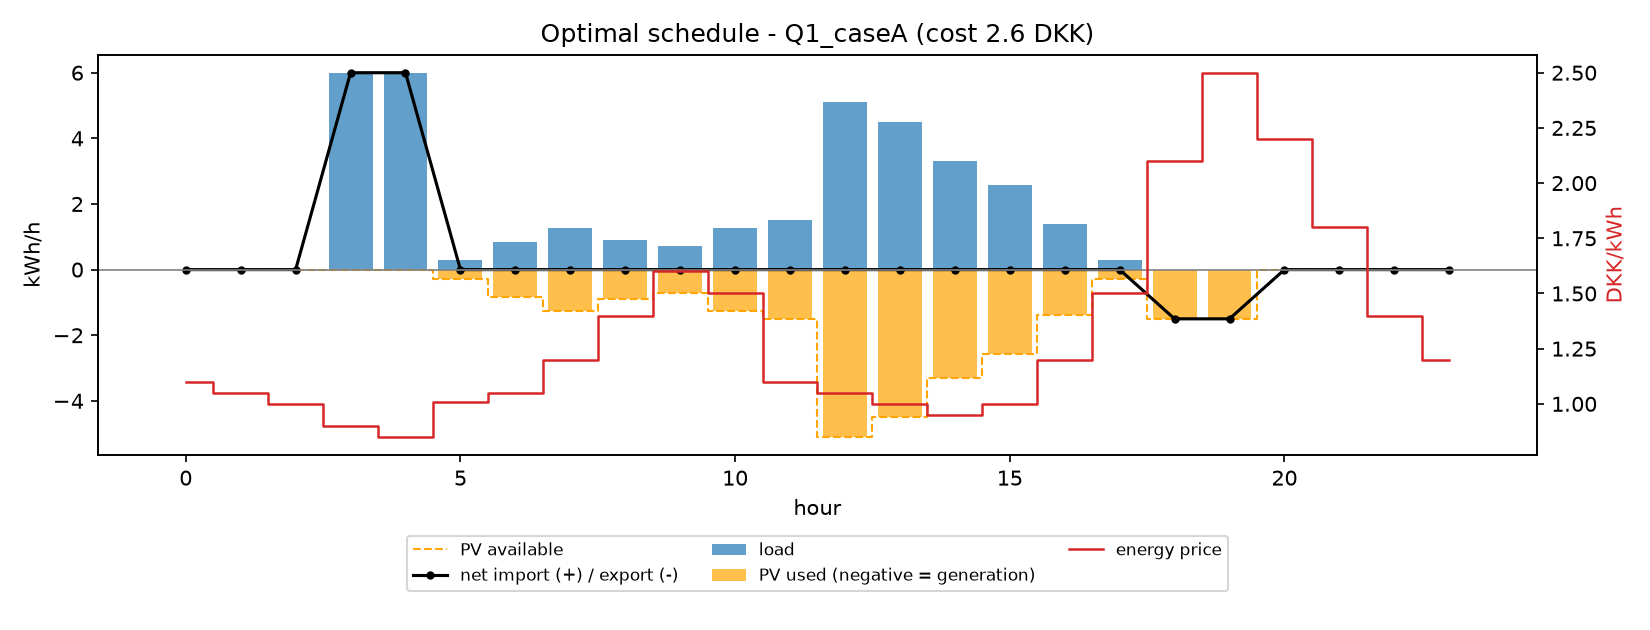

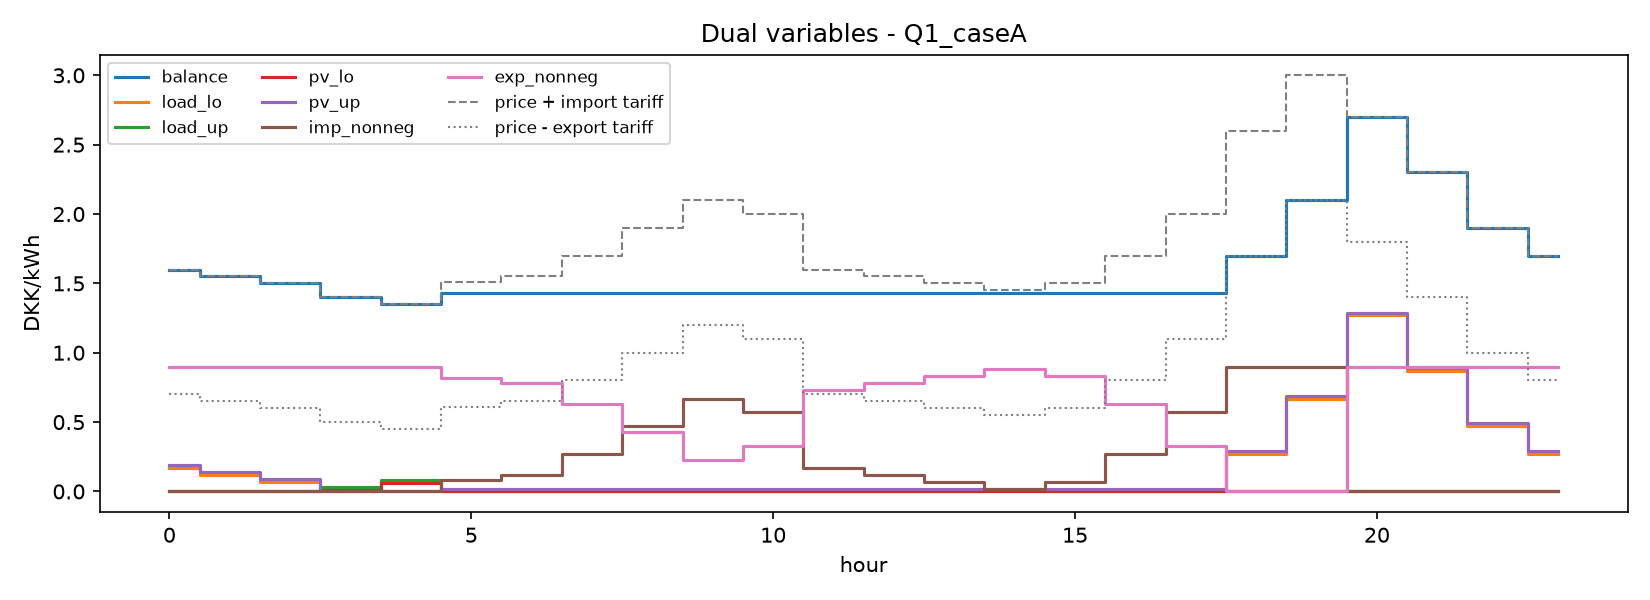


=== Q1_caseB ===
Case                 : Q1_caseB
Consumer             : C_01_B
Energy price         : mean 1.32, min 0.85, max 2.50 DKK/kWh
Import/export tariff : 0.50 / 0.40 DKK/kWh
PV                   : 6.0 kW peak, 26.9 kWh available/day, marginal cost 1.47 DKK/kWh
Load bounds          : 0.0 - 6.0 kWh/h
Consumption utility  : 1.43
Min daily energy     : None
Reference profile    : no
Disutility lin/quad  : None / None
Battery              : no
Next-day forecasts   : yes 

Restricted license - for non-production use only - expires 2027-11-29
status: OPTIMAL | objective: 1.95 DKK (utility 17.16 - cost 15.21)
daily totals (kWh): import=12.0, export=3.0, load=12.0, pv=3.0 


Outputs written to C:\Users\Alejandro\Desktop\46750 Optimization\Assignment_1\Assignment-1-optimization-power-markets\results\Q1_caseB

OK   power balance                    0.00e+00
OK   constraint violated (max g)      0.00e+00
OK   import and export together       0.00e+00
OK   lambda = p_imp in import hours   

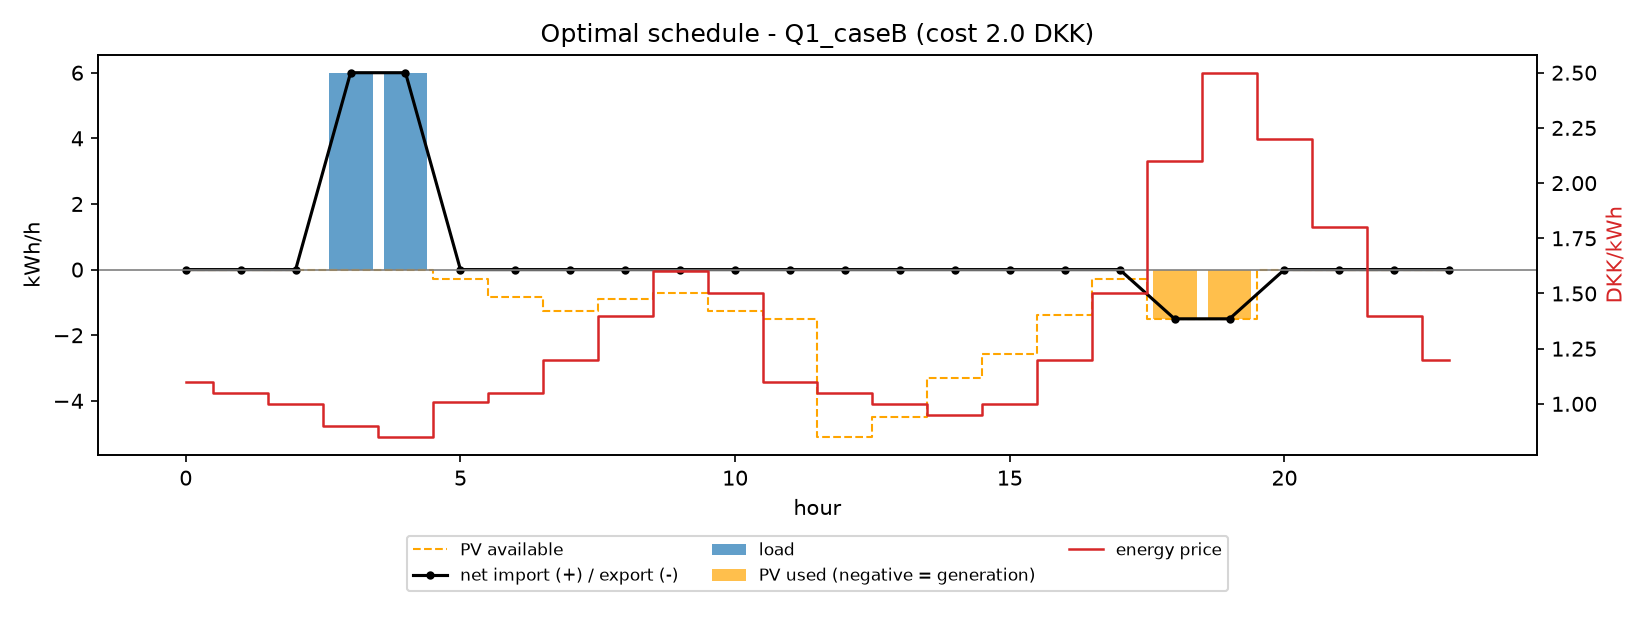

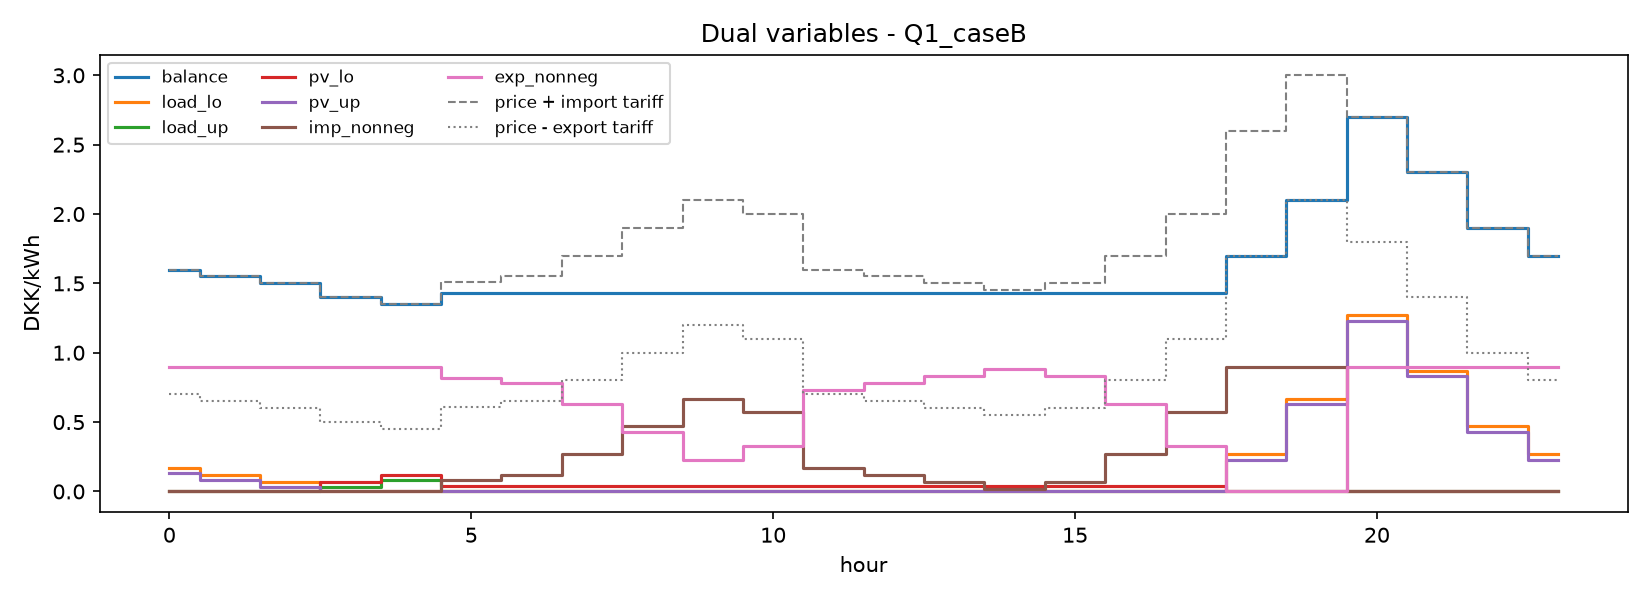

In [24]:
for question in ["Q1_caseA", "Q1_caseB"]:
    print(f"\n=== {question} ===")
    print(run_main(question))
    checks = verify(question)
    for name, (err, tol_k) in checks.items():
        print(f"{'OK  ' if err < tol_k else 'FAIL'} {name:32s} {err:.2e}")
    assert all(err < tol_k for err, tol_k in checks.values()), f"{question}: some check failed"
    for fig in ["schedule.png", "duals.png"]:
        display(Image(filename=str(RESULTS_DIR / question / fig)))